In [4]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from src.dataset import load_data
from src.model import Autoencoder
from src.train import reconstruction_error, find_best_threshold, evaluate

sns.set_style("whitegrid")

X_train, X_val, y_val, X_test, y_test = load_data(csv_path="../data/creditcard.csv")

device = "cpu"
model = Autoencoder(input_dim=30, latent_dim=6)
model.load_state_dict(torch.load("../outputs/model.pt", map_location=device))
model.eval()

errors_val = reconstruction_error(model, X_val, device)
threshold, _ = find_best_threshold(errors_val, y_val)
errors_test = reconstruction_error(model, X_test, device)

print(f"Threshold: {threshold:.6f}")

Threshold: 3.584747


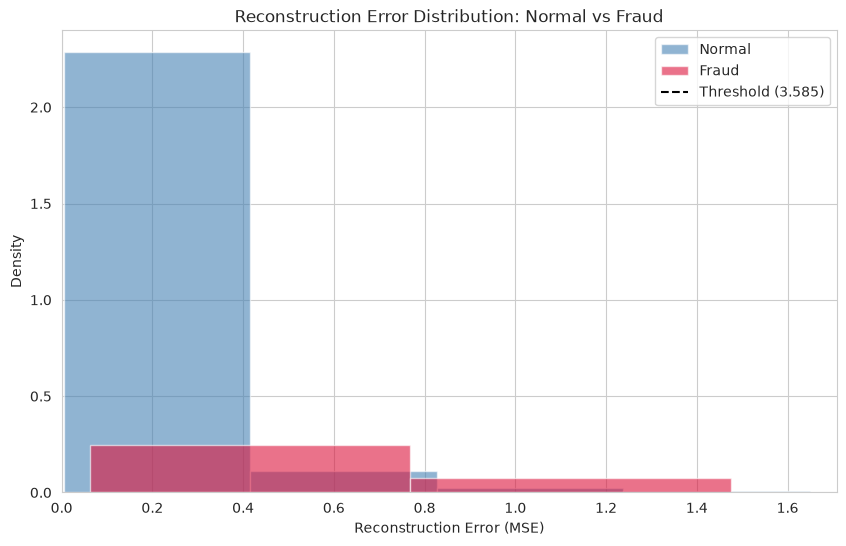

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(errors_test[y_test == 0], bins=100, alpha=0.6, label="Normal", color="steelblue", density=True)
plt.hist(errors_test[y_test == 1], bins=100, alpha=0.6, label="Fraud", color="crimson", density=True)
plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold ({threshold:.3f})")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution: Normal vs Fraud")
plt.legend()
plt.xlim(0, np.percentile(errors_test, 99.5))  # clip extreme outliers for readability
plt.savefig("../outputs/reconstruction_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

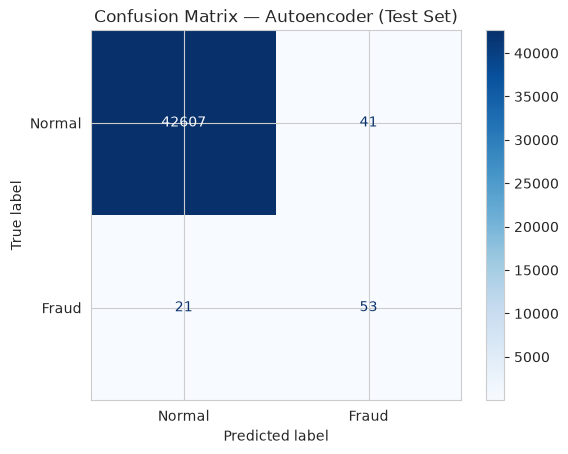

True Negatives (Normal correctly classified): 42607
False Positives: 41
False Negatives (Fraud missed): 21
True Positives (Fraud caught): 53


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = (errors_test > threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraud"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Autoencoder (Test Set)")
plt.savefig("../outputs/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"True Negatives (Normal correctly classified): {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives (Fraud missed): {cm[1,0]}")
print(f"True Positives (Fraud caught): {cm[1,1]}")

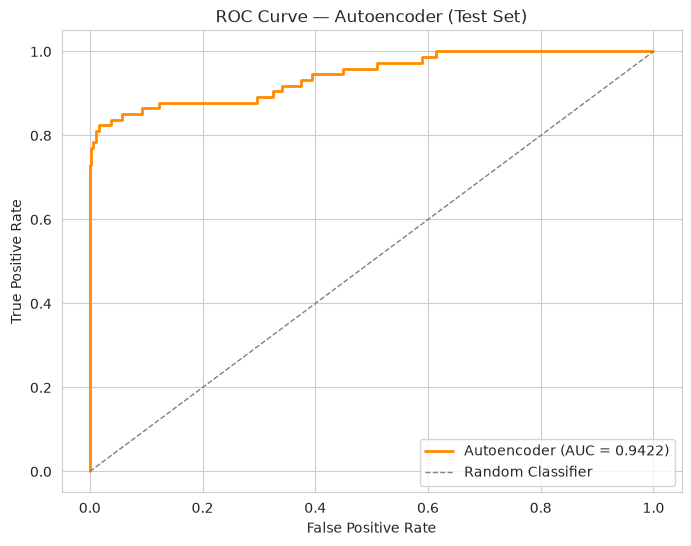

In [7]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, errors_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Autoencoder (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Autoencoder (Test Set)")
plt.legend(loc="lower right")
plt.savefig("../outputs/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

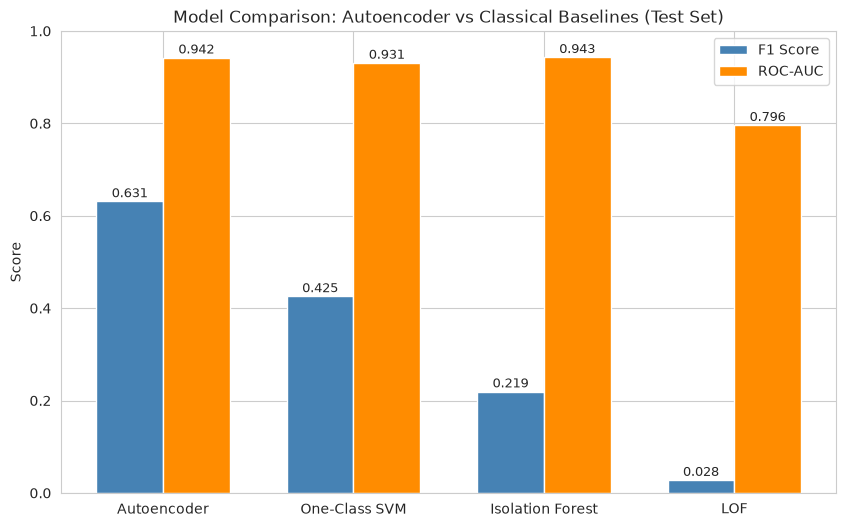

In [8]:
models = ["Autoencoder", "One-Class SVM", "Isolation Forest", "LOF"]
f1_scores = [0.6310, 0.4255, 0.2194, 0.0278]
roc_aucs = [0.9422, 0.9308, 0.9431, 0.7960]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, f1_scores, width, label="F1 Score", color="steelblue")
bars2 = ax.bar(x + width/2, roc_aucs, width, label="ROC-AUC", color="darkorange")

ax.set_ylabel("Score")
ax.set_title("Model Comparison: Autoencoder vs Classical Baselines (Test Set)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.0)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.savefig("../outputs/baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()